In [26]:
import os.path

import numpy as np
import pandas as pd

from dataclasses import dataclass

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment

## 1. 数据输入

In [27]:
DATA_PATH = "./students003.txt"
OUT_PATH = "./output/agnes/4"

In [28]:
def load_data(data_path=None):
    assert data_path is not None, "Please provide a valid data path"
    df = pd.read_csv(
        data_path,
        sep="\t",
        names=["time", "id", "x", "y"],
        dtype={"time": int, "id": int, "x": float, "y": float},
    )
    return df

df = load_data(DATA_PATH)
# df = df[df["time"]>200]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17953 entries, 0 to 17952
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    17953 non-null  int64  
 1   id      17953 non-null  int64  
 2   x       17953 non-null  float64
 3   y       17953 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 561.2 KB


 ## 2. 参数配置

In [29]:
@dataclass
class ClusterConfig:
    v_alpha: float = 1
    history_alpha: float = 0.1
    min_clusters: int = 2
    distance_threshold: float = 1.4
    pos_history_window: int = 3
    vote_history_window: int = 6
    linkage: str = "complete"

CFG = ClusterConfig()
CFG

ClusterConfig(v_alpha=1, history_alpha=0.1, min_clusters=2, distance_threshold=1.4, pos_history_window=3, vote_history_window=6, linkage='complete')

## 3. 预处理与速度特征

In [30]:
def add_velocity_features(df):
    df = df.copy()
    df = df.sort_values(["id", "time"]).reset_index(drop=True)
    df["vx"] = df.groupby("id")["x"].diff()
    df["vx"] = df["vx"].rolling(window=3).mean().fillna(df["vx"]).fillna(0.0)
    df["vy"] = df.groupby("id")["y"].diff()
    df["vy"] = df["vy"].rolling(window=3).mean().fillna(df["vy"]).fillna(0.0)
    return df

def add_history_diff_features(df, cfg: ClusterConfig):
    df = df.copy()
    df = df.sort_values(["id", "time"]).reset_index(drop=True)
    for i in range(2, cfg.pos_history_window+1):
        df[f"dx_{i}"] = df.groupby("id")["x"].diff(i).fillna(0.0)
        df[f"dy_{i}"] = df.groupby("id")["y"].diff(i).fillna(0.0)
    return df

def add_history_features(df, cfg: ClusterConfig):
    df = df.copy()
    df = df.sort_values(["id", "time"]).reset_index(drop=True)
    for i in range(1, cfg.pos_history_window):
        # do not diff, just shift to get the absolute position in history, which may be more stable than diff especially when the frame rate is low
        df[f"dx_{i}"] = df.groupby("id")["x"].shift(i).bfill().fillna(df["x"])
        df[f"dy_{i}"] = df.groupby("id")["y"].shift(i).bfill().fillna(df["y"])
    return df

def normalize_features(df, cfg: ClusterConfig):
    pos_cols = ["x", "y"]
    velo_cols = ["vx", "vy"]
    history_cols = []
    for i in range(1, cfg.pos_history_window):
        history_cols.extend([f"dx_{i}", f"dy_{i}"])
    df[pos_cols] = StandardScaler().fit_transform(df[pos_cols])
    df[velo_cols] = StandardScaler().fit_transform(df[velo_cols]) * cfg.v_alpha
    df[history_cols] = StandardScaler().fit_transform(df[history_cols]) * cfg.history_alpha
    return df

df = add_velocity_features(df)
df = add_history_features(df, CFG)
df = normalize_features(df, CFG)
df.head()

,time,id,x,y,vx,vy,dx_1,dy_1,dx_2,dy_2
0,0,1,0.118921,-0.540529,0.124616,-0.136282,0.011139,-0.053614,0.010374,-0.053118
1,10,1,0.205426,-0.514176,1.466114,0.371121,0.011139,-0.053614,0.010374,-0.053118
2,20,1,0.291930,-0.487741,1.466114,0.372687,0.019799,-0.050966,0.010374,-0.053118
3,30,1,0.378386,-0.461388,1.465864,0.371643,0.028459,-0.048310,0.019027,-0.050460
4,40,1,0.467606,-0.430724,1.479900,0.399310,0.037114,-0.045662,0.027680,-0.047795


## 4. 单帧聚类

In [31]:
def cluster_single_frame(frame, cfg) -> pd.DataFrame:
    frame = frame.copy().reset_index(drop=True)

    X = frame.iloc[:,2:].to_numpy(dtype=float)
    X = StandardScaler().fit_transform(X)
    X[:,2:4] *= cfg.v_alpha
    X[:,4:] *= cfg.history_alpha

    clusterer = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=cfg.distance_threshold,
        linkage=cfg.linkage,
    )
    labels = clusterer.fit_predict(X)
    n_clusters = len(set(labels))

    if n_clusters < cfg.min_clusters:
        clusterer = AgglomerativeClustering(n_clusters=min(cfg.min_clusters, len(X)), linkage='ward')
        labels = clusterer.fit_predict(X)

    frame["local_cluster"] = labels

    return frame

## 5. 处理全部帧并跨帧匹配

In [32]:
from collections import deque

def process_all_frames(df, cfg: ClusterConfig):
    df = df.copy()
    df = df.sort_values(["time", "id"]).reset_index(drop=True)

    past_affiliation = {}

    for pid in df["id"].unique():
        past_affiliation[pid] = deque(maxlen=cfg.vote_history_window)

    timesteps = sorted(df["time"].unique())
    output_rows = []
    n_total_group = 0

    for _, t in enumerate(timesteps):
        frame = df[df["time"] == t].copy().reset_index(drop=True)

        clustered_frame = cluster_single_frame(frame, cfg)

        # for pid in clustered_frame["id"].unique():
        #     while len(history_group[pid]) > 0 and history_group[pid][0][0] < times[max(0,i - cfg.vote_history_window + 1)]:
        #         history_group[pid].popleft()

        past_group_scope = []
        for pid in clustered_frame["id"].unique():
            past_group_scope.extend(past_affiliation[pid])

        past_group_scope = sorted(set(past_group_scope))
        new_group_ids = list(clustered_frame["local_cluster"].unique())
        vote_dict_rows = []
        voter_rows = []

        # iterate each cluster, collect votes from its members' past affiliation, and build the vote_dict_rows and voter_rows for matching
        for r, new_group_id in enumerate(new_group_ids):
            new_group_members = clustered_frame[clustered_frame["local_cluster"] == new_group_id]["id"]
            vote_dict = dict.fromkeys(past_group_scope, 0)
            vote_pool = []
            for ngm in new_group_members:
                if len(past_affiliation[ngm]) > 0:
                    vote_pool.extend(past_affiliation[ngm])
            if len(vote_pool) > 0:
                vote_dict.update({voted:vote_pool.count(voted) for voted in set(vote_pool)})
                vote_dict_rows.append(vote_dict)
                voter_rows.append(r)

        # run max weight matching on matching_matrix
        matched_dict = {}
        if len(vote_dict_rows) > 0 and len(past_group_scope) > 0:
            matching_matrix = np.array([[m[gid] for gid in past_group_scope] for m in vote_dict_rows])
            row_ind, col_ind = linear_sum_assignment(-matching_matrix)

            for r,c in zip(row_ind, col_ind):
                if matching_matrix[r, c] > 0:
                    matched_dict[voter_rows[r]] = past_group_scope[c]

        # assign final group id for each new group, if matched then use the matched one, otherwise assign a new group id
        for r, new_group_id in enumerate(new_group_ids):
            new_group_members = clustered_frame[clustered_frame["local_cluster"] == new_group_id]["id"]
            if r in matched_dict:
                final_group_id = matched_dict[r]
            else:
                n_total_group += 1
                final_group_id = n_total_group
            for cm in new_group_members:
                # history_group[cm].append((t,group_id))
                past_affiliation[cm].append(final_group_id)
                output_rows.append({
                    "time": t,
                    "id": cm,
                    "group_id": final_group_id,
                })

    result = pd.DataFrame(output_rows).sort_values(["time", "id"]).reset_index(drop=True)
    return result

result_df = process_all_frames(df, CFG)

## 6. 输出检查

In [33]:
group_counts = result_df[result_df["group_id"] >= 0].groupby("time")["group_id"].nunique()
group_counts.head(10)
# result_df["group_id"]

time
0      6
10    13
20    14
30    14
40    14
50    16
60    15
70    15
80    15
90    18
Name: group_id, dtype: int64

In [34]:
result_df.head(10)

,time,id,group_id
0,0,1,1
1,0,2,1
2,0,3,2
3,0,4,3
4,0,5,1
5,0,6,1
6,0,7,4
7,0,8,4
8,0,9,1
9,0,10,3


## 7. 可视化（可选）

In [35]:
import matplotlib.pyplot as plt

cmap = ["#5D8AA8", "#D0C0B0", "#E52B50", "#FFBF00", "#9966CC", "#A4C639", "#F9F8F5", "#CD9575", "#915C83", "#FAEBD7", "#008000", "#7FFFD4", "#E9D66B", "#525E55", "#87A96B", "#FF9966", "#A52A2A", "#FDEE00", "#6E7F80", "#FF2052", "#007FFF", "#F0FFFF", "#89CFF0", "#A1CAF1", "#F4C2C2", "#21ABCD", "#FAE7B5", "#FFE135", "#848482", "#98777B", "#BCD4E6", "#9F8170", "#F5F5DC", "#FFE4C4", "#FE6F5E", "#318CE7", "#CAFFCE", "#A2A2D0", "#6699CC", "#0D98BA", "#8A2BE2", "#DE5D83", "#79443B", "#0095B6", "#E3DAC9", "#CC0000", "#006A4E", "#873260", "#0070FF", "#B5A642", "#CB4154", "#66FF00", "#BF94E4", "#C32148", "#FF007F", "#08E8DE", "#F4DBFF", "#FF55A3", "#CB405F", "#004225", "#CD7F32", "#FF0040", "#FFC1CC", "#E7FEFF", "#F0DC82", "#480607", "#800020", "#DEB887", "#CC5500", "#E97451", "#8A3324", "#BD33A4", "#702963", "#007AA5", "#E03C31", "#536872", "#5F9EA0", "#91A3B0", "#006B3C", "#ED872D", "#E30022", "#FFF600", "#A67B5B", "#4B3621", "#1E4D2B", "#A3C1AD", "#C19A6B", "#78866B", "#FFFF99", "#FFEF00", "#FF0800", "#E4717A", "#00BFFF", "#592720", "#C41E3A", "#00CC99"]

def get_consistent_color(group_id):
    if group_id == -1:
        return "gray"
    else:
        np.random.seed(group_id)
        return np.random.rand(3,)

def plot_frame(result, original, time_value, x_range:tuple[float,float]|None=None, y_range:tuple[float,float]|None=None, save_to_file=False):

    # clear previous plot
    plt.clf()

    merged = original.merge(result, on=["time", "id"], how="left")
    frame = merged[merged["time"] == time_value].copy()

    plt.figure(figsize=(8, 6))
    for gid in sorted(frame["group_id"].unique()):
        sub = frame[frame["group_id"] == gid]
        if gid == -1:
            plt.scatter(sub["x"], sub["y"], label="ungrouped", s=20, color="gray", alpha=0.5)
        else:
            plt.scatter(sub["x"], sub["y"], color=cmap[(gid-1)%len(cmap)], label=f"group {gid}", s=50)

    if x_range is not None:
        plt.xlim(x_range[0], x_range[1])
    if y_range is not None:
        plt.ylim(y_range[0], y_range[1])
    plt.title(f"Time {time_value}")
    plt.xlabel("x")
    plt.ylabel("y")
    # try put the legend outside the plot, to the upper right corner

    plt.legend(loc="upper right", bbox_to_anchor=(1.21,1.))
    if save_to_file:
        os.makedirs(OUT_PATH, exist_ok=True)
        plt.savefig(os.path.join(OUT_PATH,f"time_{time_value}.png"), bbox_inches="tight")
        plt.clf()
        plt.close()
    else:
        plt.show()

<Figure size 640x480 with 0 Axes>

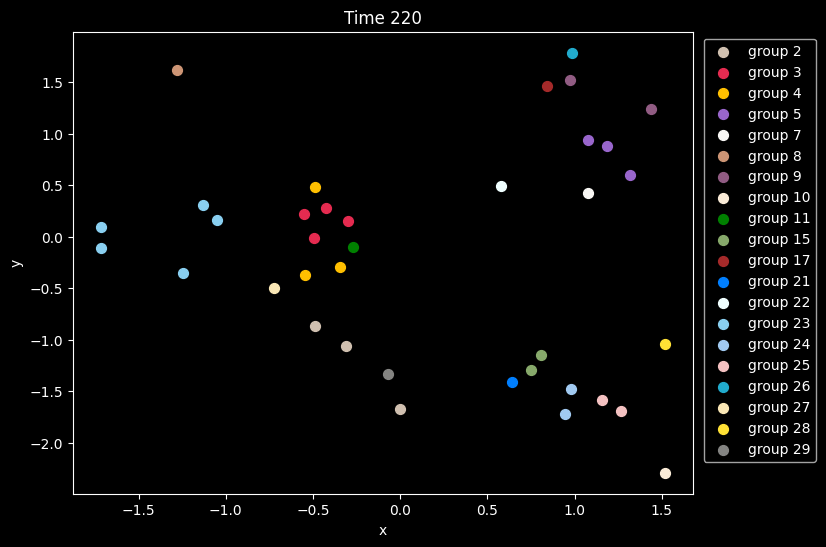

In [36]:
plot_frame(result_df, df, time_value=220)

In [37]:
for t in sorted(df["time"].unique()):
    plot_frame(result_df, df, time_value=t,
            x_range=(df['x'].min(),df['x'].max()),
            y_range=(df['y'].min(),df['y'].max()),
            save_to_file=True)

<Figure size 640x480 with 0 Axes>

## 8. 保存结果

In [39]:
OUT_CSV = "./group_labels.csv"
result_df.to_csv(OUT_CSV, index=False)
# OUT_CSV
# sorted(df["time"].unique())[:30]